In [1]:
import os 
os.chdir("/scale/user/mtannaou/alternance")
from src.visualisation.utils_colormap import CMAP
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pyresample
import pyproj

cmap_ir = CMAP.cira_ir()
cmap_sar = CMAP.cmap_sar()

def plot_sar(tensor, fig=None, ax=None, cmap=cmap_sar, title=None,
             x_lim=500, x=None, y=None):

    if ax is None:
        ax = plt.gca()

    if x is None:
        y_sar = np.linspace(-x_lim, x_lim, tensor.shape[0])
        x_sar = np.linspace(-x_lim, x_lim, tensor.shape[1])
        x_sar, y_sar = np.meshgrid(x_sar, y_sar)
    else:
        x_sar, y_sar = x, y   # déjà 2D, pas de meshgrid

    im = ax.pcolormesh(
        x_sar,
        y_sar,
        tensor,
        cmap=cmap,
        vmin=0,
        vmax=160/1.94384449,
        shading="auto"
    )

    if x is None:
        ax.set_xlim(-x_lim, x_lim)
        ax.set_ylim(-x_lim, x_lim)

    if title is not None:
        ax.set_title(title)

    if fig is not None:
        fig.colorbar(im, ax=ax, orientation="horizontal")

    ax.set_aspect("equal")


def plot_ir(tensor, fig=None, x=None, y=None, ax=None, x_lim=500,
            cmap=cmap_ir, vmin=-100, vmax=50):

    if ax is None:
        ax = plt.gca()

    tensor = np.squeeze(tensor)
    ny, nx = tensor.shape  # ny = rows, nx = cols

    if x is None:
        x = np.linspace(-x_lim, x_lim, nx)

    if y is None:
        y = np.linspace(-x_lim, x_lim, ny)

    im = ax.pcolormesh(
        x, y, tensor,
        cmap=cmap,
        shading="nearest",
        vmin=vmin,
        vmax=vmax
    )

    if x is None or y is None:
        ax.set_xlim(-x_lim, x_lim)
        ax.set_ylim(-x_lim, x_lim)
    else:
        ax.set_xlim(np.min(x), np.max(x))
        ax.set_ylim(np.min(y), np.max(y))
    ax.set_aspect("equal")

    if fig is not None:
        fig.colorbar(im, ax=ax, orientation="horizontal")
    

    
def build_storm_centered_dataset(
    ir, ir_lon, ir_lat,
    wind, wind_lon, wind_lat,
    center_lat, center_lon,
    half_size=500,
    dxy=2.0,
    kind="nearest"
):
    """
    Construit un dataset centré cyclone sur grille régulière [-500, 500] km.

    Returns
    -------
    xr.Dataset
    """

    nx = ny = int(2 * half_size / dxy) + 1

    x = np.linspace(-half_size, half_size, nx)
    y = np.linspace(half_size, -half_size, ny)  # nord en haut

    proj = pyproj.Proj(              #place le cyclone au centre (0,0), et je mesure tout en km autou
        proj="aeqd",
        lat_0=center_lat,
        lon_0=center_lon,
        ellps="WGS84",
        units="km"
    )


    ir_lon, ir_lat = pyresample.utils.check_and_wrap(ir_lon, ir_lat)
    lon2d, lat2d = np.meshgrid(longitude, latitude)

    swath_ir = pyresample.SwathDefinition(
        lon2d,
        lat2d
    )

    area_def = pyresample.geometry.AreaDefinition(
        "storm",
        "storm centered grid",
        "storm",
        proj.srs,
        nx,
        ny,
        (x[0] - dxy/2, y[-1] - dxy/2, x[-1] + dxy/2, y[0] + dxy/2)
    )

    if kind == "nearest":
        ir_grid = pyresample.kd_tree.resample_nearest(
            swath_ir,
            ir,
            area_def,
            radius_of_influence=100000,
            fill_value=np.nan
        )
    else:
        ir_grid = pyresample.kd_tree.resample_gauss(
            swath_ir,
            ir,
            area_def,
            radius_of_influence=100000,
            sigmas=25000
        )

    wind_lon, wind_lat = pyresample.utils.check_and_wrap(wind_lon, wind_lat)
    swath_wind = pyresample.SwathDefinition(wind_lon, wind_lat)

    wind_grid = pyresample.kd_tree.resample_nearest(
        swath_wind,
        wind,
        area_def,
        radius_of_influence=100000,
        fill_value=np.nan
    )

    ds = xr.Dataset(
        data_vars=dict(
            ir=(["y", "x"], ir_grid),
            wind=(["y", "x"], wind_grid),
        ),
        coords=dict(
            x=x,
            y=y,
        )
    )

    ds["center_lat"] = center_lat
    ds["center_lon"] = center_lon

    return ds

## Temporal mode

In [2]:
import os 
os.chdir("/scale/user/mtannaou/alternance")
import torch
import src.IR_to_SAR.ML_IR_SAR.model as model_ir_sar
import src.IR_to_SAR.ML_IR_SAR.config as config
os.chdir("/scale/user/mtannaou/alternance/best_result_so_far")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt = torch.load(
    "temporale_mode/best_regression_model.pt",
    map_location=device
)

cfg = config.IR_SAR_Config.from_yaml(
    "/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/config.yaml"
)
cfg.img_size = 256
cfg.in_channels = 12
cfg.out_channels = 12
cfg.block_out_channels = [16,16,32,64]
temporal_model = model_ir_sar.create_model(
    cfg=cfg,
    conditional_model=cfg.conditional_model,
    in_channels=cfg.in_channels
)

temporal_model.load_state_dict(ckpt["model"])

temporal_model = temporal_model.to(device)
temporal_model.eval()
print("model téléchargé, device :<",temporal_model.device,">")
import pickle as pkl
with open("temporale_mode/stats_normalisation.pkl","rb") as f:
    temporal_stats = pkl.load(f)
print(temporal_stats.keys())

/home/mtannaou/conda-env/ml_unet_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


model téléchargé, device :< cpu >
dict_keys(['mean_sar', 'std_sar', 'mean_x', 'std_x'])


## Regression Model


In [3]:
import os 
os.chdir("/scale/user/mtannaou/alternance")
import torch
import src.IR_to_SAR.ML_IR_SAR.model as model_ir_sar
import src.IR_to_SAR.ML_IR_SAR.config as config
os.chdir("/scale/user/mtannaou/alternance/best_result_so_far")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt = torch.load(
    "regression/best_regression_model.pt",
    map_location=device
)

cfg = config.IR_SAR_Config.from_yaml(
    "/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/config.yaml"
)
cfg.img_size = 128
cfg.in_channels = 10
cfg.out_channels = 1
cfg.block_out_channels = [16,16,32,64]

reg_model = model_ir_sar.create_model(
    cfg=cfg,
    conditional_model=cfg.conditional_model,
    in_channels=cfg.in_channels
)
print(cfg.in_channels)
print(reg_model.config.in_channels)
print(reg_model.conv_in.weight.shape)
reg_model.load_state_dict(ckpt["model"])

reg_model = reg_model.to(device)
reg_model.eval()
print("model téléchargé, device :<",reg_model.device,">")
import pickle as pkl
with open("regression/stats_normalisation/OUTPUT/stats.pkl","rb") as f:
    reg_stats = pkl.load(f)
reg_stats.keys()

10
10
torch.Size([16, 10, 3, 3])
model téléchargé, device :< cpu >


dict_keys(['normalisation_type', 'std_sar', 'mean_sar', 'mean_x', 'std_x'])

## FLOW Matching Model

In [4]:
import os 
os.chdir("/scale/user/mtannaou/alternance")
import torch
import src.IR_to_SAR.ML_IR_SAR.model as model_ir_sar
import src.IR_to_SAR.ML_IR_SAR.config as config
os.chdir("/scale/user/mtannaou/alternance/best_result_so_far")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt = torch.load(
    "residual_flow_matching/best_fm_resid_model.pt",
    map_location=device
)

cfg = config.IR_SAR_Config.from_yaml(
    "/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/config.yaml"
)
cfg.img_size = 128
cfg.in_channels = 2
cfg.out_channels = 1
cfg.block_out_channels = [16,16,32,64]
fm_model = model_ir_sar.create_model(
    cfg=cfg,
    conditional_model=cfg.conditional_model,
    in_channels=cfg.in_channels
)

fm_model.load_state_dict(ckpt["model"])

fm_model = fm_model.to(device)
fm_model.eval()
print("model téléchargé, device :<",fm_model.device,">")
import pickle as pkl
with open("residual_flow_matching/stats_normalisation/OUTPUT/stats.pkl","rb") as f:
    fm_stats = pkl.load(f)
fm_stats.keys()

model téléchargé, device :< cpu >


dict_keys(['normalisation_type', 'std_sar', 'mean_sar', 'mean_x', 'std_x'])

In [ ]:
import os
import re
from datetime import datetime, timedelta


years = [2017, 2018, 2019]

irar_path = "/scale/project/ifremer-isi-jumeaunumerique/IRAR_BestTrack_corrected"


def get_datetime(filename):
    """
    Extrait la date après '_s'.

    Exemple :
    TC-IRAR_v02r02_AL012020_s20200516233015_e20200516233015.nc
                             ^^^^^^^^^^^^^^
    """
    match = re.search(r"_s(\d{14})", filename)

    if match is None:
        return None

    return datetime.strptime(match.group(1), "%Y%m%d%H%M%S")


# ============================================================
# LISTES INTERMÉDIAIRES
# ============================================================

# Tous les AEQD trouvés
aeqd_all = []

# AEQD passant le filtre +/- 2 h toutes les 30 min
aeqd_valid_30min = []

# Séquences 9 fichiers associées au filtre 30 min
paths_30min_before_filter24 = []


# ============================================================
# LISTES FINALES
# ============================================================
# IMPORTANT :
# ces deux listes auront exactement la même longueur
# et le même AEQD à l'indice i.

# Chaque élément contient 9 paths :
# -2h, -1h30, -1h, -30min, AEQD, +30min, +1h, +1h30, +2h
paths_30min = []

# Chaque élément contient 49 paths :
# -24h, -23h, ..., -1h, AEQD, +1h, ..., +23h, +24h
paths_24h = []

# Nom/path du fichier AEQD correspondant
aeqd_final = []


# ============================================================
# PARCOURS
# ============================================================

for year in years:

    year_path = os.path.join(irar_path, str(year))

    for cyc_id in os.listdir(year_path):

        cyc_id_path = os.path.join(year_path, cyc_id)

        if not os.path.isdir(cyc_id_path):
            continue

        files = os.listdir(cyc_id_path)

        # ----------------------------------------------------
        # Construire un dictionnaire :
        #
        # datetime -> path du fichier STANDARD
        #
        # On exclut volontairement les fichiers aeqd ici.
        # Cela évite que l'AEQD écrase l'observation normale
        # ayant le même timestamp.
        # ----------------------------------------------------

        obs_by_time = {}

        for filename in files:

            if not filename.endswith(".nc"):
                continue

            if "aeqd" in filename:
                continue

            dt = get_datetime(filename)

            if dt is None:
                continue

            obs_by_time[dt] = os.path.join(
                cyc_id_path,
                filename
            )

        # ----------------------------------------------------
        # Récupérer les AEQD
        # ----------------------------------------------------

        aeqd_files = [
            f
            for f in files
            if "aeqd" in f and f.endswith(".nc")
        ]

        for aeqd_filename in aeqd_files:

            aeqd_path = os.path.join(
                cyc_id_path,
                aeqd_filename
            )

            aeqd_time = get_datetime(aeqd_filename)

            if aeqd_time is None:
                continue

            # =================================================
            # CONDITION 1 : fichier AEQD
            # =================================================

            aeqd_all.append(aeqd_path)


            # =================================================
            # CONDITION 2 :
            # 4 avant et 4 après, fréquence 30 minutes
            #
            # Total :
            # 4 + AEQD + 4 = 9 paths
            # =================================================

            times_30min_before = [
                aeqd_time - timedelta(minutes=30 * i)
                for i in range(4, 0, -1)
            ]

            times_30min_after = [
                aeqd_time + timedelta(minutes=30 * i)
                for i in range(1, 5)
            ]


            valid_30min = (
                all(t in obs_by_time for t in times_30min_before)
                and
                all(t in obs_by_time for t in times_30min_after)
            )

            if not valid_30min:
                continue


            # Construire la séquence dans l'ordre chronologique
            sequence_30min = (
                [obs_by_time[t] for t in times_30min_before]
                +
                [aeqd_path]
                +
                [obs_by_time[t] for t in times_30min_after]
            )


            aeqd_valid_30min.append(aeqd_path)
            paths_30min_before_filter24.append(sequence_30min)


            # =================================================
            # CONDITION 3 :
            #
            # 24 observations avant toutes les heures
            # +
            # AEQD
            # +
            # 24 observations après toutes les heures
            #
            # Total = 49 paths
            # =================================================

            times_24h_before = [
                aeqd_time - timedelta(hours=i)
                for i in range(24, 0, -1)
            ]

            times_24h_after = [
                aeqd_time + timedelta(hours=i)
                for i in range(1, 25)
            ]


            valid_24h = (
                all(t in obs_by_time for t in times_24h_before)
                and
                all(t in obs_by_time for t in times_24h_after)
            )

            if not valid_24h:
                continue


            sequence_24h = (
                [obs_by_time[t] for t in times_24h_before]
                +
                [aeqd_path]
                +
                [obs_by_time[t] for t in times_24h_after]
            )


            # =================================================
            # STOCKAGE FINAL
            #
            # On ajoute sequence_30min seulement ici !
            #
            # Donc paths_30min contient uniquement les AEQD qui
            # passent AUSSI le filtre 24 h.
            # =================================================

            paths_30min.append(sequence_30min)
            paths_24h.append(sequence_24h)
            aeqd_final.append(aeqd_path)


# ============================================================
# RÉSULTATS
# ============================================================

print("==============================================")
print("RÉSULTATS")
print("==============================================")

print(f"Condition 1 - Nombre total de AEQD          : {len(aeqd_all)}")

print(
    f"Condition 2 - AEQD avec +/- 4 obs à 30 min : "
    f"{len(aeqd_valid_30min)}"
)

print(
    f"Condition 3 - également +/- 24 h à 1 h     : "
    f"{len(aeqd_final)}"
)

print()
print("Nombre de séquences finales 30 min :", len(paths_30min))
print("Nombre de séquences finales 24 h   :", len(paths_24h))


# ============================================================
# VÉRIFICATIONS
# ============================================================

assert len(paths_30min) == len(paths_24h)
assert len(paths_30min) == len(aeqd_final)

assert all(len(sequence) == 9 for sequence in paths_30min)
assert all(len(sequence) == 49 for sequence in paths_24h)

# Vérifier que le fichier du milieu est bien le même AEQD
for i in range(len(aeqd_final)):

    assert paths_30min[i][4] == aeqd_final[i]

    assert paths_24h[i][24] == aeqd_final[i]


print("\nToutes les vérifications sont OK.")

RÉSULTATS
Condition 1 - Nombre total de AEQD          : 874
Condition 2 - AEQD avec +/- 4 obs à 30 min : 740
Condition 3 - également +/- 24 h à 1 h     : 242

Nombre de séquences finales 30 min : 242
Nombre de séquences finales 24 h   : 242

Toutes les vérifications sont OK.


In [ ]:
import xarray as xr;from tqdm import tqdm;import numpy as np
import os
os.chdir("/scale/user/mtannaou/alternance")
import src.IR_to_SAR.data_preparation.regrid_era5.regrid_era5 as regrid_colocs

# données pour era5
era5_path = "src/extract_cyclones_era5/era5_single_levels"
janvier, mars, mai, juillet, aout, octobre, decembre = (
    np.arange(1, 32, 1),
    np.arange(1, 32, 1),
    np.arange(1, 32, 1),
    np.arange(1, 32, 1),
    np.arange(1, 32, 1),
    np.arange(1, 32, 1),
    np.arange(1, 32, 1),
)
avril, juin, septembre, novembre = (
    np.arange(1, 31, 1),
    np.arange(1, 31, 1),
    np.arange(1, 31, 1),
    np.arange(1, 31, 1),
)

reg_tensor = []
y_regression = []
valid_reg_indices = []

for enu, obs in enumerate(tqdm(paths_30min,desc="Création du set pour la rgeression ...",total=len(paths_30min))):
    # if enu == 1:
    #     break
    obs_tensor = []
    try : 
        for i, path in enumerate(obs):
            ds = xr.open_dataset(path)
            obs_tensor.append(ds["ir_aeqd"].values[501//2-128//2:501//2+128//2,501//2-128//2:501//2+128//2] - 273.15)
            if i ==4:
                basename = os.path.basename(path)
                cyclone_id = basename.split("_")[2].lower()
                date = basename.split("_e")[-1].split("_")[0]
                year = date[:4];month = date[4:6];day=date[6:8]
                hour = date[8:10];minute=date[10:12]
                year_path = os.path.join(era5_path,str(year))
                fevrier = np.arange(1, 29, 1) if int(year) % 4 != 0 else np.arange(1, 30, 1)
                months = [
                        janvier, fevrier, mars, avril, mai, juin,
                        juillet, aout, septembre, octobre, novembre, decembre,
                    ]
                ndays = 0
                for i_era5 in range(int(month) - 1):
                    ndays += len(months[i_era5])
                ndays += int(day)
                ndays_str = "0" + str(ndays) if len(str(ndays)) < 3 else str(ndays)
                dayera5_path = os.path.join(year_path, ndays_str)
                nc_path = ""
                for nc_file in os.listdir(dayera5_path):
                    if cyclone_id in nc_file:
                        nc_path = os.path.join(dayera5_path, nc_file)
                        break
                reg_era5 = np.array(regrid_colocs.regrid_files_era5(
                    [nc_path],
                    "/scale/user/mtannaou/alternance/src/IR_to_SAR/data_preparation/"
                    "regrid_era5/regridded_era5",
                    resolution_km=2,
                    grid_size_km=256,
                    index_hour=int(hour) - 1 + int(minute) // 30,
                ))
                
                y = ds["wind_aeqd"].values[501//2-128//2:501//2+128//2,501//2-128//2:501//2+128//2]
            if i == 8:
                obs_tensor.append(reg_era5.squeeze() - 273.15)
        reg_tensor.append(obs_tensor)
        y_regression.append(y)
        valid_reg_indices.append(enu)

    except Exception as e :
        print(e)
        continue    

reg_tensor = np.array(reg_tensor)
y_regression = np.array(y_regression)

paths_24h = [paths_24h[i] for i in valid_reg_indices if i < len(paths_24h)]

print(y_regression.shape,reg_tensor.shape)

temporal_tensor = []
y_temporal = []
valid_temporal_indices = []

for enu, obs in enumerate(tqdm(paths_24h,desc="Création du set pour les séquences temporelles ...",total=len(paths_24h))):
    obs_tensor = []
    y_tensor = []
    try :
        for i, path in enumerate(obs):
            ds = xr.open_dataset(path)
            
            obs_tensor.append(ds["ir_aeqd"].values[501//2-256//2:501//2+256//2,501//2-256//2:501//2+256//2] - 273.15)
            if "aeqd" in os.path.basename(path):
                y_tensor.append(ds["wind_aeqd"].values[501//2-256//2:501//2+256//2,501//2-256//2:501//2+256//2])
            else : 
                y_tensor.append(np.full((256, 256), np.nan))

        temporal_tensor.append(obs_tensor)
        y_temporal.append(y_tensor)
        valid_temporal_indices.append(enu)

    except Exception as e: 
        print(e)
        continue

paths_24h = [paths_24h[i] for i in valid_temporal_indices]

reg_tensor = reg_tensor[valid_temporal_indices]
y_regression = y_regression[valid_temporal_indices]

temporal_tensor = np.array(temporal_tensor)
y_temporal = np.array(y_temporal)

fm_tensor = reg_tensor
y_flow_matching = y_regression

print(y_regression.shape, reg_tensor.shape)
print(fm_tensor.shape, y_flow_matching.shape)
print(temporal_tensor.shape, y_temporal.shape)

In [7]:
print(y_regression.shape, reg_tensor.shape)
print(fm_tensor.shape, y_flow_matching.shape)
print(temporal_tensor.shape, y_temporal.shape)

(50, 128, 128) (50, 10, 128, 128)
(50, 10, 128, 128) (50, 128, 128)
(50, 49, 256, 256) (50, 49, 256, 256)


In [8]:
## Prédiction de regression
import torch;import src.IR_to_SAR.data_preparation.data_preprocessing as dataprep
from src.IR_to_SAR.ML_IR_SAR.flow_matching_inference import generate_ensemble, compute_uncertainty_maps,generate_residual_ensemble
import json
with open(
    "/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/training_results/flow_matching_residual/residual_stats_9_v0.json",
    "r"
) as f:
    resid_stats = json.load(f)

n_members = 20
num_steps = 50
N = reg_tensor.shape[0];H = reg_tensor.shape[-2];W = reg_tensor.shape[-1]
y_pred_regression = np.zeros((N, H, W),dtype=np.float32)
y_pred_flow_matching = np.zeros((N, n_members, H, W),dtype=np.float32)
reg_model.eval();fm_model.eval()
device = next(reg_model.parameters()).device
for ind, sample in enumerate(tqdm(reg_tensor,desc="generating regression + FM predictions ...",total=N)):
    sample = sample.copy()
    for c in range(sample.shape[0]):
        sample[c] = (sample[c]- reg_stats["mean_x"][c]) / reg_stats["std_x"][c]
    x_torch = (torch.from_numpy(sample).float().unsqueeze(0).to(device))
    with torch.no_grad():
        mean_pred_norm = reg_model(
            x_torch,
            timestep=0
        ).sample

        ensemble_norm = generate_residual_ensemble(
            fm_model=fm_model,
            mean_pred=mean_pred_norm,
            residual_mean=resid_stats["mean"],
            residual_std=resid_stats["std"],
            n_members=n_members,
            num_steps=num_steps,
        )
    mean_pred_np = (
        mean_pred_norm
        .detach()
        .cpu()
        .numpy()
    )

    mean_pred_phys = dataprep.annular_denormalization(
        mean_pred_np[0],
        stats={
            "mean": reg_stats["mean_sar"],
            "std": reg_stats["std_sar"]
        }
    )[0].squeeze()

    y_pred_regression[ind] = (
        mean_pred_phys
    )

    ensemble_np = (
        ensemble_norm
        .detach()
        .cpu()
        .numpy()
    )
    ensemble_phys = ensemble_np*fm_stats["std_sar"] + fm_stats["mean_sar"]

    y_pred_flow_matching[ind] = (
        ensemble_phys[:, 0]
    )

generating regression + FM predictions ...: 100%|██████████| 50/50 [08:21<00:00, 10.03s/it]


In [9]:
N = temporal_tensor.shape[0]
H = 256
W = 256
n_positions = 12

y_pred_temporal = np.full(
    (N, n_positions, H, W),
    np.nan,
    dtype=np.float32
)

temporal_model.eval()
device = next(temporal_model.parameters()).device

for n in tqdm(
    range(N),
    desc="generating temporal predictions ..."
):

    sequence = temporal_tensor[n]
    target_idx = 24
    for target_position in range(n_positions):
        indices = [
            target_idx + 2 * (j - target_position)
            for j in range(n_positions)
        ]

        if min(indices) < 0 or max(indices) >= len(sequence):
            continue

        x = sequence[indices].copy()

        x = (x - temporal_stats["mean_x"])/temporal_stats["std_x"]

        x_torch = (
            torch.from_numpy(x)
            .float()
            .unsqueeze(0)
            .to(device)
        )

        with torch.no_grad():

            pred = temporal_model(
                x_torch,
                timestep=0
            ).sample

        pred = (
            pred
            .squeeze(0)
            .detach()
            .cpu()
            .numpy()
        )
        for c in range(pred.shape[0]):
            pred[c] = dataprep.annular_denormalization(pred[c].reshape((1,256,256)), stats={"mean":temporal_stats["mean_sar"],"std":temporal_stats["std_sar"]})[0].squeeze()

        pred_target = pred[target_position]

        y_pred_temporal[
            n,
            target_position
        ] = pred_target

generating temporal predictions ...:   0%|          | 0/50 [00:00<?, ?it/s]

generating temporal predictions ...: 100%|██████████| 50/50 [05:03<00:00,  6.08s/it]


In [10]:
import pickle
import numpy as np

mean_flow_matching = np.nanmean(
    y_pred_flow_matching,
    axis=1
)

mean_temporal_256 = np.nanmean(
    y_pred_temporal,
    axis=1
)

H, W = mean_temporal_256.shape[-2:]

mean_temporal = mean_temporal_256[
    :,
    H//2 - 64:H//2 + 64,
    W//2 - 64:W//2 + 64
]

predictions = {
    "SAR": y_regression,
    "regression": y_pred_regression,
    "mean_flow_matching": mean_flow_matching,
    "mean_temporal": mean_temporal
}

print("SAR :", predictions["SAR"].shape)
print("regression :", predictions["regression"].shape)
print("mean_flow_matching :", predictions["mean_flow_matching"].shape)
print("mean_temporal :", predictions["mean_temporal"].shape)

with open("best_result_so_far/predictions.pkl", "wb") as f:
    pickle.dump(predictions, f)

SAR : (50, 128, 128)
regression : (50, 128, 128)
mean_flow_matching : (50, 128, 128)
mean_temporal : (50, 128, 128)


In [11]:
import numpy as np


def compute_vmax_rmax(field, pixel_size_km=2.0):
    if np.all(np.isnan(field)):
        return np.nan, np.nan

    vmax = np.nanmax(field)

    flat_idx = np.nanargmax(field)
    y_max, x_max = np.unravel_index(flat_idx, field.shape)

    H, W = field.shape

    cy = (H - 1) / 2
    cx = (W - 1) / 2

    rmax_pixel = np.sqrt(
        (y_max - cy)**2
        + (x_max - cx)**2
    )

    rmax_km = rmax_pixel * pixel_size_km

    return vmax, rmax_km


N = y_regression.shape[0]

vmax_target = np.full(N, np.nan)
rmax_target = np.full(N, np.nan)

vmax_regression = np.full(N, np.nan)
rmax_regression = np.full(N, np.nan)

vmax_flow_matching = np.full(N, np.nan)
rmax_flow_matching = np.full(N, np.nan)

vmax_temporal = np.full(N, np.nan)
rmax_temporal = np.full(N, np.nan)


for i in range(N):

    target = y_regression[i]

    vmax_target[i], rmax_target[i] = compute_vmax_rmax(
        target
    )


    regression = y_pred_regression[i]

    vmax_regression[i], rmax_regression[i] = compute_vmax_rmax(
        regression
    )


    flow_matching = np.nanmean(
        y_pred_flow_matching[i],
        axis=0
    )

    vmax_flow_matching[i], rmax_flow_matching[i] = compute_vmax_rmax(
        flow_matching
    )


    temporal = np.nanmean(
        y_pred_temporal[i],
        axis=0
    )

    H, W = temporal.shape

    temporal_crop = temporal[
        H//2 - 64:H//2 + 64,
        W//2 - 64:W//2 + 64
    ]

    vmax_temporal[i], rmax_temporal[i] = compute_vmax_rmax(
        temporal_crop
    )


print("Shapes :")
print("target :", vmax_target.shape, rmax_target.shape)
print("regression :", vmax_regression.shape, rmax_regression.shape)
print("flow matching :", vmax_flow_matching.shape, rmax_flow_matching.shape)
print("temporal :", vmax_temporal.shape, rmax_temporal.shape)

Shapes :
target : (50,) (50,)
regression : (50,) (50,)
flow matching : (50,) (50,)
temporal : (50,) (50,)


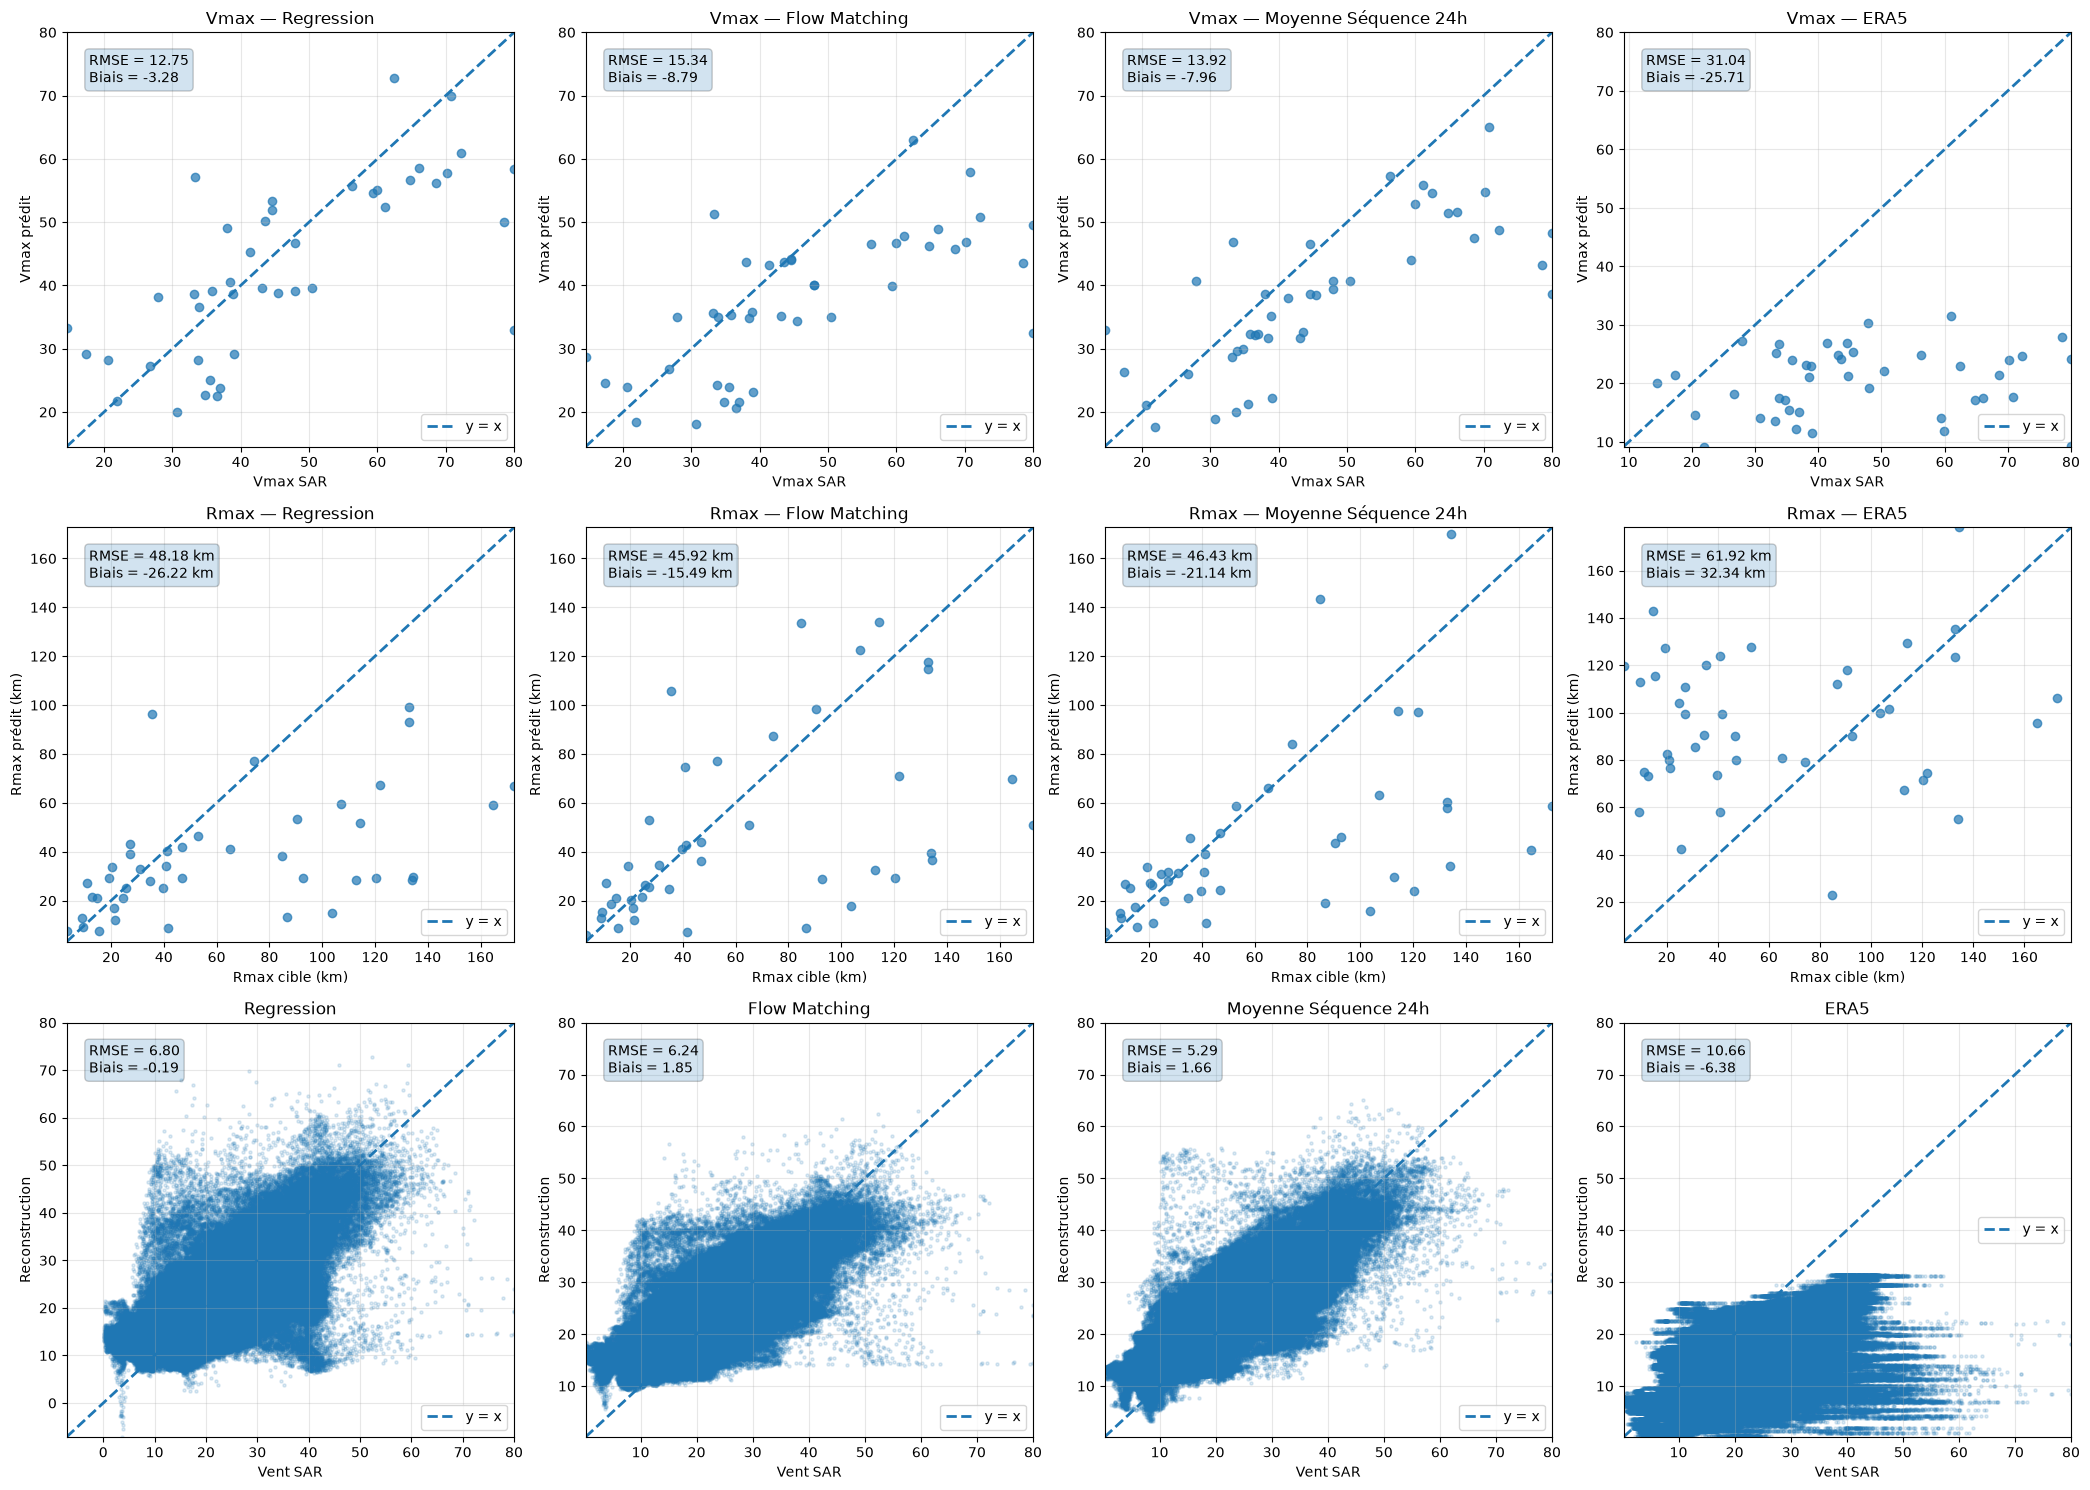

In [29]:
import numpy as np
import matplotlib.pyplot as plt


def rmse(y_true, y_pred):
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return np.sqrt(np.mean((y_pred[mask] - y_true[mask])**2))


def bias(y_true, y_pred):
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return np.mean(y_pred[mask] - y_true[mask])


# ============================================================
# Récupération des champs ERA5
# ============================================================

era5_fields = []

for i in range(len(reg_tensor)):
    era5 = reg_tensor[i][-1] + 273.15

    # Si tensor PyTorch
    if hasattr(era5, "detach"):
        era5 = era5.detach().cpu().numpy()

    era5_fields.append(np.squeeze(era5))

era5_fields = np.asarray(era5_fields)


# ============================================================
# Calcul de Vmax ERA5
# ============================================================

vmax_era5 = np.asarray([
    np.nanmax(field)
    for field in era5_fields
])


# ============================================================
# Calcul de Rmax ERA5
# ============================================================
# Ici je suppose que :
# - le cyclone est centré dans l'image
# - résolution = 2 km/pixel
# Adapte si nécessaire.

resolution_km = 2.0

rmax_era5 = []

for field in era5_fields:

    h, w = field.shape

    cy = (h - 1) / 2
    cx = (w - 1) / 2

    if np.all(~np.isfinite(field)):
        rmax_era5.append(np.nan)
        continue

    iy, ix = np.unravel_index(
        np.nanargmax(field),
        field.shape
    )

    distance_pixels = np.sqrt(
        (iy - cy)**2 +
        (ix - cx)**2
    )

    rmax_era5.append(
        distance_pixels * resolution_km
    )

rmax_era5 = np.asarray(rmax_era5)


# ============================================================
# Figure
# ============================================================

fig, axes = plt.subplots(
    3, 4,
    figsize=(21, 15)
)


vmax_predictions = [
    vmax_regression,
    vmax_flow_matching,
    vmax_temporal,
    vmax_era5
]

rmax_predictions = [
    rmax_regression,
    rmax_flow_matching,
    rmax_temporal,
    rmax_era5
]

pixel_predictions = [
    y_pred_regression,
    mean_flow_matching,
    mean_temporal,
    era5_fields
]

names = [
    "Regression",
    "Flow Matching",
    "Moyenne Séquence 24h",
    "ERA5"
]


# ============================================================
# Ligne 1 : Vmax
# ============================================================

for j, (pred, name) in enumerate(zip(vmax_predictions, names)):

    true = np.asarray(vmax_target)
    pred = np.asarray(pred)

    mask = np.isfinite(true) & np.isfinite(pred)

    true_valid = true[mask]
    pred_valid = pred[mask]

    current_rmse = rmse(true, pred)
    current_bias = bias(true, pred)

    ax = axes[0, j]

    ax.scatter(
        true_valid,
        pred_valid,
        alpha=0.7
    )

    vmin = min(
        np.min(true_valid),
        np.min(pred_valid)
    )

    vmax = max(
        np.max(true_valid),
        np.max(pred_valid)
    )

    ax.plot(
        [vmin, vmax],
        [vmin, vmax],
        "--",
        linewidth=2,
        label="y = x"
    )

    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)

    ax.set_xlabel("Vmax SAR")
    ax.set_ylabel("Vmax prédit")
    ax.set_title(f"Vmax — {name}")

    ax.text(
        0.05,
        0.95,
        f"RMSE = {current_rmse:.2f}\n"
        f"Biais = {current_bias:.2f}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            alpha=0.2
        )
    )

    ax.grid(alpha=0.3)
    ax.legend()


# ============================================================
# Ligne 2 : Rmax
# ============================================================

for j, (pred, name) in enumerate(zip(rmax_predictions, names)):

    true = np.asarray(rmax_target)
    pred = np.asarray(pred)

    mask = np.isfinite(true) & np.isfinite(pred)

    true_valid = true[mask]
    pred_valid = pred[mask]

    current_rmse = rmse(true, pred)
    current_bias = bias(true, pred)

    ax = axes[1, j]

    ax.scatter(
        true_valid,
        pred_valid,
        alpha=0.7
    )

    rmin = min(
        np.min(true_valid),
        np.min(pred_valid)
    )

    rmax = max(
        np.max(true_valid),
        np.max(pred_valid)
    )

    ax.plot(
        [rmin, rmax],
        [rmin, rmax],
        "--",
        linewidth=2,
        label="y = x"
    )

    ax.set_xlim(rmin, rmax)
    ax.set_ylim(rmin, rmax)

    ax.set_xlabel("Rmax cible (km)")
    ax.set_ylabel("Rmax prédit (km)")
    ax.set_title(f"Rmax — {name}")

    ax.text(
        0.05,
        0.95,
        f"RMSE = {current_rmse:.2f} km\n"
        f"Biais = {current_bias:.2f} km",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            alpha=0.2
        )
    )

    ax.grid(alpha=0.3)
    ax.legend()


# ============================================================
# Ligne 3 : comparaison pixel à pixel
# ============================================================

for j, (pred, name) in enumerate(zip(pixel_predictions, names)):

    true_pixels = []
    pred_pixels = []

    for i in range(y_regression.shape[0]):

        sar_true = np.asarray(y_regression[i])

        sar_pred = pred[i]

        if hasattr(sar_pred, "detach"):
            sar_pred = sar_pred.detach().cpu().numpy()

        sar_pred = np.squeeze(np.asarray(sar_pred))
        sar_true = np.squeeze(sar_true)

        mask = (
            np.isfinite(sar_true)
            & np.isfinite(sar_pred)
        )

        true_pixels.append(
            sar_true[mask]
        )

        pred_pixels.append(
            sar_pred[mask]
        )

    true_pixels = np.concatenate(true_pixels)
    pred_pixels = np.concatenate(pred_pixels)

    current_rmse = np.sqrt(
        np.mean(
            (pred_pixels - true_pixels)**2
        )
    )

    current_bias = np.mean(
        pred_pixels - true_pixels
    )

    ax = axes[2, j]

    ax.scatter(
        true_pixels,
        pred_pixels,
        alpha=0.15,
        s=5
    )

    pmin = min(
        np.nanmin(true_pixels),
        np.nanmin(pred_pixels)
    )

    pmax = max(
        np.nanmax(true_pixels),
        np.nanmax(pred_pixels)
    )

    ax.plot(
        [pmin, pmax],
        [pmin, pmax],
        "--",
        linewidth=2,
        label="y = x"
    )

    ax.set_xlim(pmin, pmax)
    ax.set_ylim(pmin, pmax)

    ax.set_xlabel("Vent SAR")
    ax.set_ylabel("Reconstruction")
    ax.set_title(name)

    ax.text(
        0.05,
        0.95,
        f"RMSE = {current_rmse:.2f}\n"
        f"Biais = {current_bias:.2f}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            alpha=0.2
        )
    )

    ax.grid(alpha=0.3)
    ax.legend()


plt.tight_layout()
plt.show()

In [13]:
ind = -1

Text(0.5, 1.0, 'Vmax = 32.33416748046875')

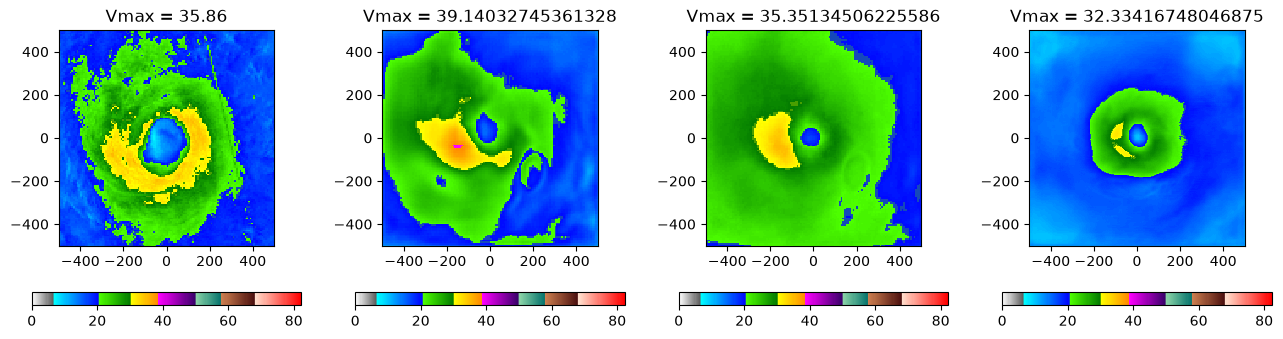

In [ ]:
ind  += 1
fig, axes = plt.subplots(1,5,figsize=(5*4,4))
plot_sar(y_regression[ind],ax=axes[0],fig=fig);axes[0].set_title(f"Vmax = {np.nanmax(y_regression[ind])}")
plot_sar(y_pred_regression[ind],ax=axes[1],fig=fig);axes[1].set_title(f"Vmax = {np.nanmax(y_pred_regression[ind])}")
plot_sar(y_pred_flow_matching[ind].mean(axis=0),ax=axes[2],fig=fig);axes[2].set_title(f"Vmax = {np.nanmax(y_pred_flow_matching[ind].mean(axis=0))}")
plot_sar(y_pred_temporal[ind].mean(axis=0),ax=axes[3],fig=fig);axes[3].set_title(f"Vmax = {np.nanmax(y_pred_temporal[ind].mean(axis=0))}")